In [1]:
import pandas as pd
import numpy as np
import matplotlib as mtp

In [2]:
df_gdp = pd.read_csv('arquivos_base/gdp.csv', decimal='.', thousands=',')

In [3]:
df_gdp

,Country,Region,Year,GDP_pp
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1901,613.99
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1906,624.04
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1911,634.25
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1916,647.28
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1921,662.40
...,...,...,...,...
4414,Zimbabwe,Sub-Saharan Africa,1/1/1991,782.09
4415,Zimbabwe,Sub-Saharan Africa,1/1/1996,781.50
4416,Zimbabwe,Sub-Saharan Africa,1/1/2001,719.96
4417,Zimbabwe,Sub-Saharan Africa,1/1/2006,520.17


In [4]:
df_gdp.info()

<class 'pandas.DataFrame'>
RangeIndex: 4419 entries, 0 to 4418
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Country   4419 non-null   str    
 1   Region    4419 non-null   str    
 2   Year      4419 non-null   str    
 3    GDP_pp   4419 non-null   float64
dtypes: float64(1), str(3)
memory usage: 138.2 KB


In [5]:
df_gdp.columns = 'Country', 'Region', 'Year', 'GDP_pp'
# erro ao chamar coluna 'GDP_pp'. Resolvido declarando colunas

In [6]:
df_gdp['Year'] = df_gdp['Year'].apply(lambda x: int(x.split('/')[2]))
# transformando coluna Year para INT, para facilitar operacao

# INFORME O PRIMEIRO VALOR REGISTRADO DE CADA PAIS

In [7]:
df_gdp['Year'].value_counts()
# nao ha uma confirmacao de aparicoes exatas dos paises por ano, oscila a quantidade de aparicoes conforme o ano.
# portanto na primeira amostragem ha risco de ter algum pais que inicie sua amostragem em um ano diferente dos demais.

Year
1991    193
1996    193
2001    193
1901    192
1906    192
1911    192
1916    192
1921    192
1926    192
1931    192
1936    192
1941    192
1946    192
1951    192
1956    192
1961    192
1966    192
1971    192
1976    192
1981    192
1986    192
2006    192
2011    192
Name: count, dtype: int64

In [8]:
df_gdp.groupby('Country').agg({'Year':'min'}).reset_index().sort_values(by='Year')
# um dos paises inicia a amostragem em 1991, diferente dos outros paises. Pais -> 'Kosovo'

,Country,Year
0,Afghanistan,1901
122,Netherlands,1901
123,New Zealand,1901
124,Nicaragua,1901
125,Niger,1901
...,...,...
67,Guinea-Bissau,1901
68,Guyana,1901
59,Georgia,1901
192,Zimbabwe,1901


In [9]:
df_ano_minimo = df_gdp.groupby('Country').agg({'Year':'min', 'GDP_pp':'first'}).reset_index()

In [10]:
df_ano_minimo
# amostragem do primeiro valor registrado de cada pais

,Country,Year,GDP_pp
0,Afghanistan,1901,613.99
1,Albania,1901,1062.01
2,Algeria,1901,1807.76
3,Andorra,1901,3352.50
4,Angola,1901,525.76
...,...,...,...
188,Venezuela,1901,766.21
189,Vietnam,1901,572.96
190,"Yemen, Rep.",1901,729.39
191,Zambia,1901,532.38


# Informe as regioes com maior crescimento de PIB per capita no seculo passado

In [11]:
df_gdp['Year'].value_counts().sort_index()
# seculo passado ==  1996 <=

Year
1901    192
1906    192
1911    192
1916    192
1921    192
1926    192
1931    192
1936    192
1941    192
1946    192
1951    192
1956    192
1961    192
1966    192
1971    192
1976    192
1981    192
1986    192
1991    193
1996    193
2001    193
2006    192
2011    192
Name: count, dtype: int64

In [12]:
df_gdp_crescimento = df_gdp.groupby(['Year', 'Region']).agg({'GDP_pp':'mean'}).reset_index()

In [13]:
df_gdp_crescimento = df_gdp_crescimento.loc[(df_gdp_crescimento['Year'] == 1901) | (df_gdp_crescimento['Year'] == 1996)]
# selecionando dados de inicio e final (ate encerramento do seculo) para retornar a diferenca de valores

In [14]:
df_gdp_crescimento.rename(columns={'GDP_pp':'GDP_inicial'}, inplace=True)
# formatacao do DF

In [15]:
df_operacional = df_gdp_crescimento[df_gdp_crescimento['Year'] == 1996].reset_index()
# criando um DF de manipulacao dos dados

In [16]:
df_gdp_crescimento.drop(df_gdp_crescimento[df_gdp_crescimento['Year'] == 1996].index, axis=0, inplace=True)
df_gdp_crescimento.drop(columns='Year', inplace=True)
# formatacao

In [17]:
df_gdp_crescimento['GDP_final'] = df_operacional['GDP_inicial']
# alinhando valores pra executar diferenca de valores

In [18]:
df_gdp_crescimento['GDP_diferenca'] = ((df_gdp_crescimento['GDP_final'] / df_gdp_crescimento['GDP_inicial'])-1) * 100
# formulando a operacao de diferenca

In [19]:
df_gdp_crescimento.sort_values(by='GDP_diferenca').reset_index().drop(columns='index').tail(3)
# As 3 regioes com os maiores crescimentos de PIB no seculo passado (ordem crescente)

,Region,GDP_inicial,GDP_final,GDP_diferenca
5,Europe,2583.788478,17932.684894,594.046167
6,Asia,900.756296,7311.992963,711.761516
7,"Middle East, North Africa, and Greater Arabia",1164.350000,11145.343913,857.215950


# Preencha os anos ausentes em cada pais com uma estimativa, baseada na diferenca entre o proximo registro e o anterior

In [20]:
year_p = df_gdp['Year'].sort_values().value_counts().index.to_list()
year_f = []
for ano in range(min(year_p), max(year_p)):
    if ano not in year_p:
        year_f.append(ano)

d_years_off = np.array(year_f)

In [21]:
df_gdp.sort_values(["Country", "Year"], inplace=True)

In [22]:
df_gdp['delta_gdp'] = df_gdp['GDP_pp'] - df_gdp['GDP_pp'].shift(1)
df_gdp['delta_year'] = df_gdp['Year'] - df_gdp['Year'].shift(1)
df_gdp['delta_gdp_year'] = (df_gdp['delta_gdp'] / df_gdp['delta_year']).shift(-1)

In [23]:
df_gdp['next_year'] = df_gdp['Year'].shift(-1)
del df_gdp['delta_gdp'], df_gdp['delta_year']

In [24]:
df_new_data = pd.DataFrame()
for idx, row in df_gdp.iterrows():
    if row['Year'] == 2011:
        continue

    years_to_add = d_years_off[(d_years_off < row ['next_year']) & (d_years_off > row['Year'])]

    for new_year in years_to_add:
        add_row = row.copy()
        add_row['GDP_pp'] = add_row['GDP_pp'] + (add_row['delta_gdp_year'] * (new_year - add_row['Year']))
        add_row['Year'] = new_year
        add_row['kind'] = 'estimated'
        df_new_data = pd.concat([df_new_data, pd.DataFrame([add_row])], ignore_index=True)


In [25]:
df_gdp = pd.concat([df_gdp, df_new_data])
df_gdp.sort_values(by=['Country', 'Year'], inplace=True)

In [26]:
df_gdp.index = df_gdp['Year']

In [27]:
df_gdp['kind'] = df_gdp['kind'].fillna('real')

In [28]:
df_gdp[df_gdp['Country'] == 'Brazil']

,Country,Region,Year,GDP_pp,delta_gdp_year,next_year,kind
Year,,,,,,,
1901,Brazil,South America,1901,648.480,9.698000,1906.0,real
1902,Brazil,South America,1902,658.178,9.698000,1906.0,estimated
1903,Brazil,South America,1903,667.876,9.698000,1906.0,estimated
1904,Brazil,South America,1904,677.574,9.698000,1906.0,estimated
1905,Brazil,South America,1905,687.272,9.698000,1906.0,estimated
...,...,...,...,...,...,...,...
2007,Brazil,South America,2007,9150.558,308.128000,2011.0,estimated
2008,Brazil,South America,2008,9458.686,308.128000,2011.0,estimated
2009,Brazil,South America,2009,9766.814,308.128000,2011.0,estimated


<Axes: xlabel='Year', ylabel='GDP_pp'>

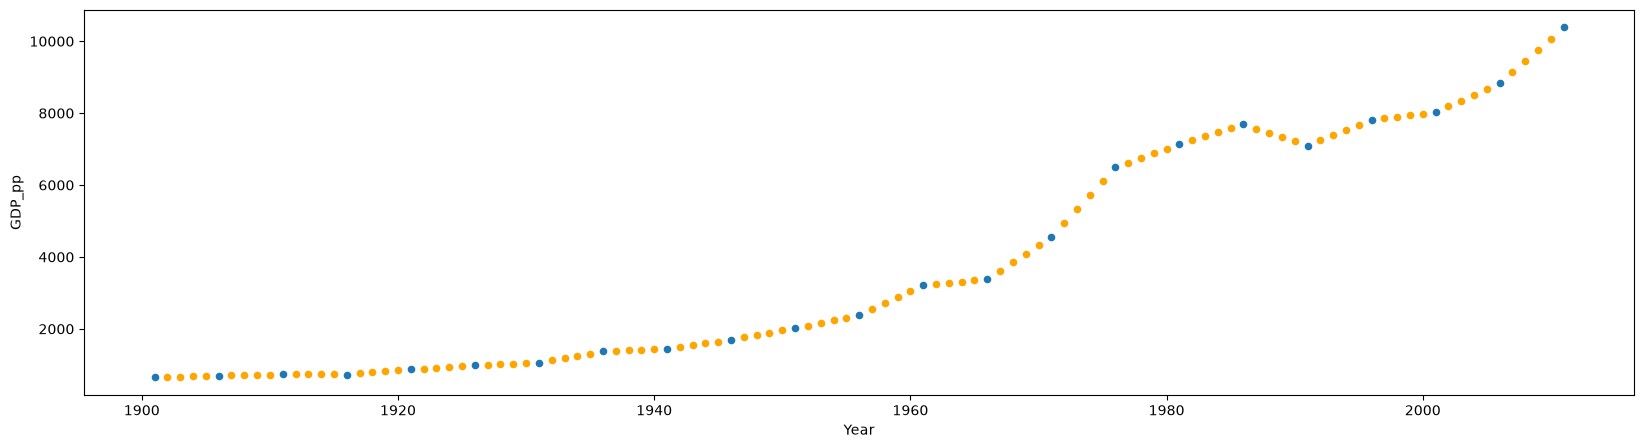

In [29]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(20, 5))

country = 'Brazil'
df_gdp[(df_gdp['kind'] == 'real') & (df_gdp['Country'] == country)].plot(kind='scatter', y='GDP_pp', x='Year', ax=ax)
df_gdp[(df_gdp['kind'] == 'estimated') & (df_gdp['Country'] == country)].plot(kind='scatter', y='GDP_pp', x='Year', ax=ax, color='orange')



In [30]:
df_gdp['Year'] = df_gdp['Year'].astype(int)
df_gdp['GDP_pp'] = df_gdp['GDP_pp'].astype(float)



In [31]:
import plotly.express as px

df = px.data.gapminder()
dict_iso_alpha =df.set_index('country').to_dict()['iso_alpha']
dict_num = {j: i for i, j in enumerate(df_gdp['Country'].unique())}

In [32]:
df_gdp['iso_alpha'] = df_gdp['Country'].map(dict_iso_alpha)
df_gdp['iso_num'] = df_gdp['Country'].map(dict_num)

In [33]:
fig = px.choropleth(df_gdp[df_gdp['kind'] == 'real'].reset_index(drop=True), locations='iso_alpha', color='GDP_pp', hover_name='Country', animation_frame='Year')
fig.update_layout(height=600)
fig.show()

In [37]:
df_gdp['country-year'] = df_gdp['Country'] + '-' + df_gdp['Year'].apply(lambda x: str(int(x))).values
dict_gdp_year = df_gdp.set_index('country-year').to_dict()['GDP_pp']